In [2]:
import pandas as pd

In [3]:
df = pd.read_csv(r'F:\Data Science Series\Machine Learning\3.Ridge vs Lasso Regression\Weather Prediction\weather_dataset_2025.csv')
print(df.head())

         Date    City  Temperature_C  Humidity_%  Wind_Speed_km_h  \
0  2025-01-01  Riyadh           15.8          94             21.0   
1  2025-01-01  Jeddah           31.5          54             25.3   
2  2025-01-01  Dammam           30.4          33              8.6   
3  2025-01-01   Dubai           34.0          37             18.7   
4  2025-01-01    Doha           28.3          32              6.8   

   Precipitation_mm      Condition  
0              0.00         Cloudy  
1              3.71          Windy  
2              3.14  Partly Cloudy  
3              0.00          Foggy  
4              0.00          Rainy  


In [4]:
print(df.columns)

Index(['Date', 'City', 'Temperature_C', 'Humidity_%', 'Wind_Speed_km_h',
       'Precipitation_mm', 'Condition'],
      dtype='object')


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5475 entries, 0 to 5474
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              5475 non-null   object 
 1   City              5475 non-null   object 
 2   Temperature_C     5475 non-null   float64
 3   Humidity_%        5475 non-null   int64  
 4   Wind_Speed_km_h   5475 non-null   float64
 5   Precipitation_mm  5475 non-null   float64
 6   Condition         5475 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 299.5+ KB
None


In [6]:
print(df.isnull().sum())

Date                0
City                0
Temperature_C       0
Humidity_%          0
Wind_Speed_km_h     0
Precipitation_mm    0
Condition           0
dtype: int64


In [21]:
y=df['Temperature_C']
X=df.drop('Temperature_C',axis=1)

In [22]:
X=X.drop('Date',axis=1)

In [23]:
X

,City,Humidity_%,Wind_Speed_km_h,Precipitation_mm,Condition
0,Riyadh,94,21.0,0.00,Cloudy
1,Jeddah,54,25.3,3.71,Windy
2,Dammam,33,8.6,3.14,Partly Cloudy
3,Dubai,37,18.7,0.00,Foggy
4,Doha,32,6.8,0.00,Rainy
...,...,...,...,...,...
5470,Sydney,71,22.9,4.88,Sunny
5471,Toronto,43,37.4,5.03,Sunny
5472,Berlin,42,23.7,10.68,Windy
5473,Mumbai,58,12.5,3.23,Cloudy


In [24]:
X = pd.get_dummies(X, drop_first=True)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1)
lasso = Lasso(alpha=0.1)

ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [28]:
ridge_pred = ridge.predict(X_test_scaled)
lasso_pred = lasso.predict(X_test_scaled)

In [29]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("Ridge:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2:", r2_score(y_test, ridge_pred))

print("\nLasso:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R2:", r2_score(y_test, lasso_pred))

Ridge:
RMSE: 11.724401358648503
R2: -0.010946984764319767

Lasso:
RMSE: 11.683927716270285
R2: -0.003979280149140507


In [30]:
lasso_coef = pd.Series(lasso.coef_, index=X.columns)
print(lasso_coef.sort_values())

City_New York             -0.282777
Condition_Windy           -0.272928
Precipitation_mm          -0.178667
Wind_Speed_km_h           -0.067358
City_Singapore            -0.063120
City_Jeddah               -0.025272
Condition_Rainy            0.000000
Condition_Foggy           -0.000000
City_Tokyo                 0.000000
Condition_Sunny            0.000000
Humidity_%                 0.000000
City_London               -0.000000
City_Dubai                -0.000000
City_Doha                  0.000000
City_Cairo                 0.000000
City_Mumbai                0.000000
City_Riyadh                0.018032
City_Paris                 0.032397
Condition_Stormy           0.038667
City_Sydney                0.114439
Condition_Partly Cloudy    0.114570
City_Dammam                0.127163
City_Toronto               0.225066
dtype: float64


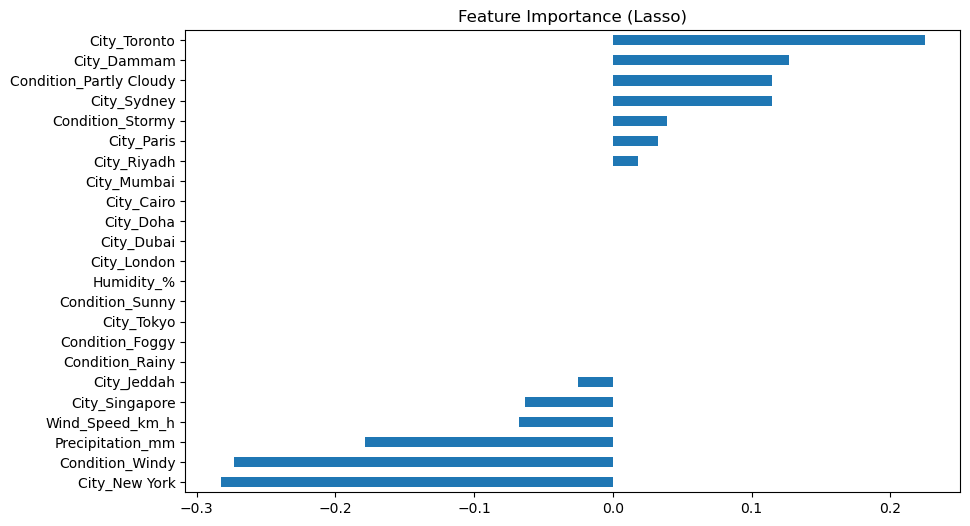

In [32]:
import matplotlib.pyplot as plt
lasso_coef.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Importance (Lasso)")
plt.show()

In [33]:
print("Ridge R2:", r2_score(y_test, ridge_pred))
print("Lasso R2:", r2_score(y_test, lasso_pred))

Ridge R2: -0.010946984764319767
Lasso R2: -0.003979280149140507
